<a href="https://colab.research.google.com/github/yeshaa23/Project-A-Kelompok-4-Pertamina-PBAGenap/blob/main/Notebook/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA)

## Import Library

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from matplotlib.ticker import MaxNLocator
import seaborn as sns

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load data hasil preprocessing

In [23]:
# Path ke file di Google Drive
file_path = '/content/drive/MyDrive/ProjectA-PBA/hasil_preprocessing_pertamina.csv'

# Baca data ke DataFrame
df = pd.read_csv(file_path)
df.head()

,Link,Judul,Isi Berita,Status,Tag,Sentimen,Penerbit,final_text_clean,final_text_stemmed,jumlah_token_before_sw,jumlah_token_after_sw
0,https://money.kompas.com/image/2017/10/03/1815...,Foto : CSR Pertamina Lubricants Kini Fokus ke ...,Diskusi mengenai CSR di industri pelumas berta...,success,Ekonomi,Neutral,Kompas,diskusi mengenai csr industri pelumas bertajuk...,diskusi kena csr industri lumas tajuk cari for...,16,13
1,https://money.kompas.com/read/2016/06/06/14280...,"Gandeng Dua Bank, Pertamina Lubricants Yakin P...","JAKARTA, KOMPAS.com - Anak perusahaan Pertamin...",success,Kecelakaan Kerja,Positive,Kompas,jakarta kompas com anak perusahaan pertamina y...,anak usaha pertamina pertamina lubricants gand...,130,95
2,https://money.kompas.com/read/2017/02/03/12195...,"Dua Pucuk Pimpinan Pertamina Dicopot, Yenni An...","JAKARTA, KOMPAS.com — Pasca-pencopotan dua puc...",success,Migas,Positive,Kompas,jakarta kompas com pasca pencopotan dua pucuk ...,pasca copot pucuk pimpin pertamina menteri bad...,145,120
3,https://money.kompas.com/read/2016/05/27/20434...,Ini yang Dilakukan PTKAM untuk Efisiensi 'Oil ...,"JAKARTA, KOMPAS.com - PT Pertamina (persero) t...",success,Gangguan Operasional,Positive,Kompas,jakarta kompas com pertamina persero telah mem...,pertamina bentuk buah program mengefesiensikan...,174,121
4,https://money.kompas.com/read/2017/03/24/11200...,Ini Tugas Pertama Adiatma Sardjito Sebagai Jub...,"JAKARTA, KOMPAS.com - Adiatma Sardjito telah r...",success,Migas,Positive,Kompas,jakarta kompas com adiatma sardjito telah resm...,adiatma sardjito resmi angkat corporate commun...,193,134


## Informasi dasar dataset

In [24]:
print("===== Info Dataset =====")
print(df.info())
print("\n===== 5 Baris Pertama =====")
display(df.head())
print("\n===== Statistik Deskriptif =====")
display(df.describe())
print("\nJumlah duplikat:", df.duplicated().sum())
print("\nMissing value per kolom:")
print(df.isnull().sum())

===== Info Dataset =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1883 entries, 0 to 1882
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Link                    1882 non-null   object
 1   Judul                   1882 non-null   object
 2   Isi Berita              1829 non-null   object
 3   Status                  1883 non-null   object
 4   Tag                     1882 non-null   object
 5   Sentimen                1883 non-null   object
 6   Penerbit                1882 non-null   object
 7   final_text_clean        1829 non-null   object
 8   final_text_stemmed      1829 non-null   object
 9   jumlah_token_before_sw  1883 non-null   int64 
 10  jumlah_token_after_sw   1883 non-null   int64 
dtypes: int64(2), object(9)
memory usage: 161.9+ KB
None

===== 5 Baris Pertama =====


,Link,Judul,Isi Berita,Status,Tag,Sentimen,Penerbit,final_text_clean,final_text_stemmed,jumlah_token_before_sw,jumlah_token_after_sw
0,https://money.kompas.com/image/2017/10/03/1815...,Foto : CSR Pertamina Lubricants Kini Fokus ke ...,Diskusi mengenai CSR di industri pelumas berta...,success,Ekonomi,Neutral,Kompas,diskusi mengenai csr industri pelumas bertajuk...,diskusi kena csr industri lumas tajuk cari for...,16,13
1,https://money.kompas.com/read/2016/06/06/14280...,"Gandeng Dua Bank, Pertamina Lubricants Yakin P...","JAKARTA, KOMPAS.com - Anak perusahaan Pertamin...",success,Kecelakaan Kerja,Positive,Kompas,jakarta kompas com anak perusahaan pertamina y...,anak usaha pertamina pertamina lubricants gand...,130,95
2,https://money.kompas.com/read/2017/02/03/12195...,"Dua Pucuk Pimpinan Pertamina Dicopot, Yenni An...","JAKARTA, KOMPAS.com — Pasca-pencopotan dua puc...",success,Migas,Positive,Kompas,jakarta kompas com pasca pencopotan dua pucuk ...,pasca copot pucuk pimpin pertamina menteri bad...,145,120
3,https://money.kompas.com/read/2016/05/27/20434...,Ini yang Dilakukan PTKAM untuk Efisiensi 'Oil ...,"JAKARTA, KOMPAS.com - PT Pertamina (persero) t...",success,Gangguan Operasional,Positive,Kompas,jakarta kompas com pertamina persero telah mem...,pertamina bentuk buah program mengefesiensikan...,174,121
4,https://money.kompas.com/read/2017/03/24/11200...,Ini Tugas Pertama Adiatma Sardjito Sebagai Jub...,"JAKARTA, KOMPAS.com - Adiatma Sardjito telah r...",success,Migas,Positive,Kompas,jakarta kompas com adiatma sardjito telah resm...,adiatma sardjito resmi angkat corporate commun...,193,134



===== Statistik Deskriptif =====


,jumlah_token_before_sw,jumlah_token_after_sw
count,1883.000000,1883.000000
mean,337.292618,254.103027
std,225.931438,166.392424
min,1.000000,1.000000
25%,221.000000,167.000000
50%,306.000000,230.000000
75%,401.000000,304.000000
max,2285.000000,1774.000000



Jumlah duplikat: 16

Missing value per kolom:
Link                       1
Judul                      1
Isi Berita                54
Status                     0
Tag                        1
Sentimen                   0
Penerbit                   1
final_text_clean          54
final_text_stemmed        54
jumlah_token_before_sw     0
jumlah_token_after_sw      0
dtype: int64


## Visualisasi EDA

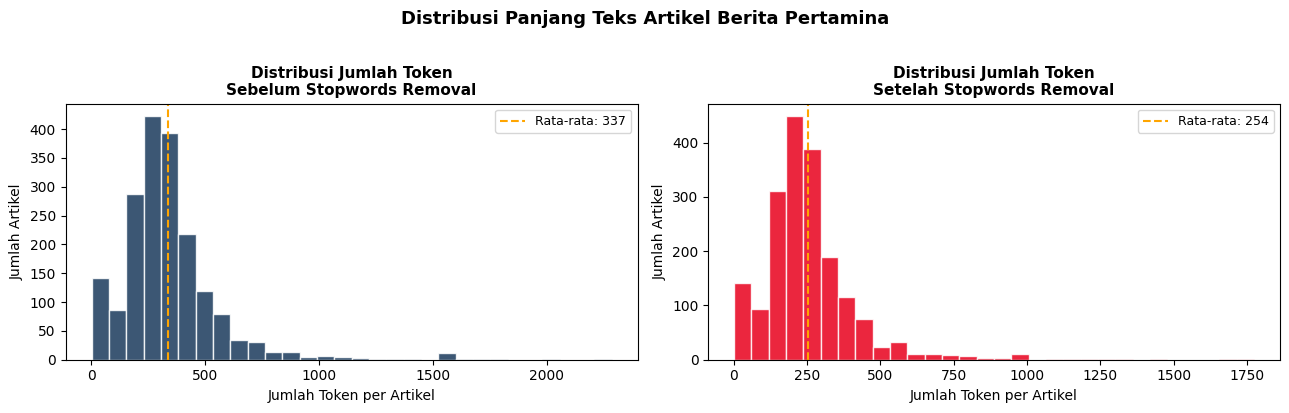

In [25]:
# Distribusi jumlah token sebelum vs sesudah stopwords removal
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, color, label in [
    (axes[0], "jumlah_token_before_sw", "#1A3A5C", "Sebelum Stopwords Removal"),
    (axes[1], "jumlah_token_after_sw",  "#E8001C", "Setelah Stopwords Removal"),
]:
    ax.hist(df[col], bins=30, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(f"Distribusi Jumlah Token\n{label}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Jumlah Token per Artikel")
    ax.set_ylabel("Jumlah Artikel")
    mean_val = df[col].mean()
    ax.axvline(mean_val, color="orange", linestyle="--", linewidth=1.5, label=f"Rata-rata: {mean_val:.0f}")
    ax.legend(fontsize=9)
fig.suptitle("Distribusi Panjang Teks Artikel Berita Pertamina", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("1_distribusi_token")

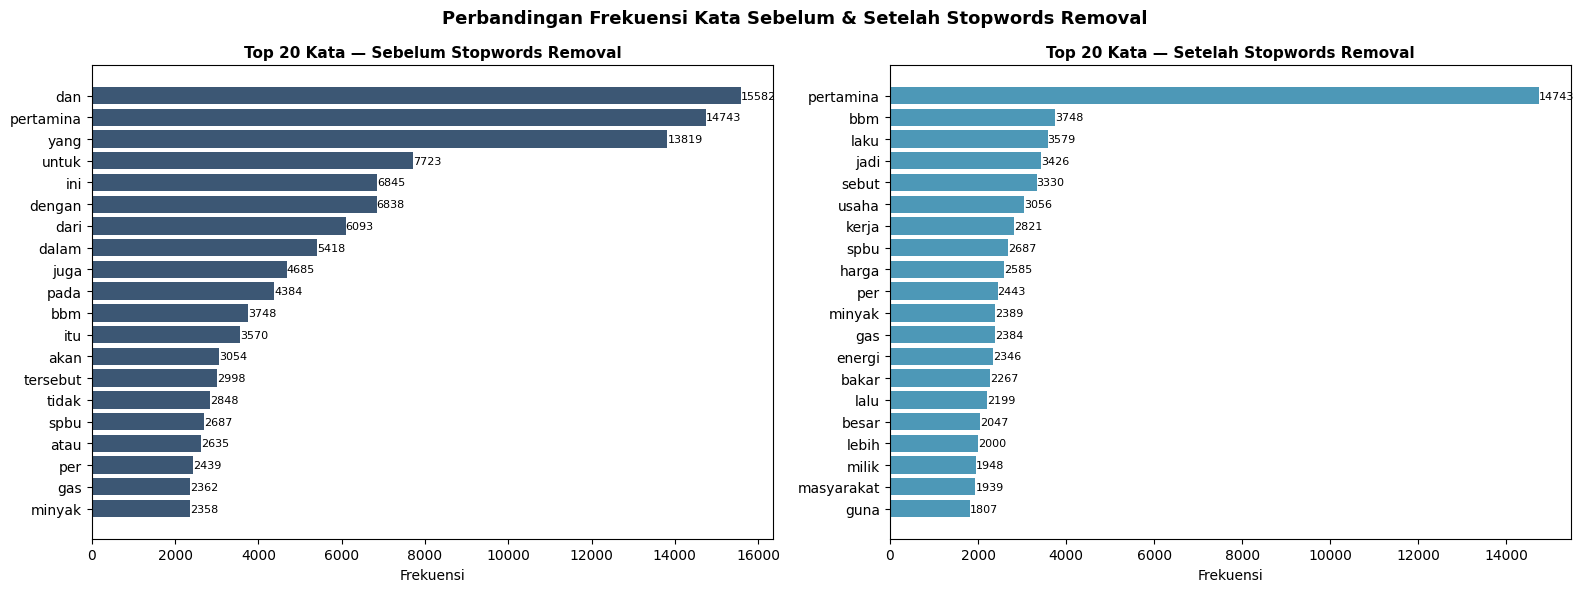

In [26]:
from collections import Counter

# Gabungkan semua teks dari kolom 'final_text_clean' dan 'final_text_stemmed'
all_text_before_sw = ' '.join(df['final_text_clean'].dropna())
all_text_after_sw = ' '.join(df['final_text_stemmed'].dropna())

# Hitung frekuensi kata sebelum stopwords removal
words_before = all_text_before_sw.split()
freq_before = Counter(words_before)

# Hitung frekuensi kata setelah stopwords removal
words_after = all_text_after_sw.split()
freq_after = Counter(words_after)

# Top 20 kata sebelum vs sesudah stopwords
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, freq, color, title in [
    (axes[0], freq_before, "#1A3A5C", "Top 20 Kata — Sebelum Stopwords Removal"),
    (axes[1], freq_after,  "#2E86AB", "Top 20 Kata — Setelah Stopwords Removal"),
]:
    data = pd.DataFrame(freq.most_common(20), columns=["Kata", "Frekuensi"])
    bars = ax.barh(data["Kata"][::-1], data["Frekuensi"][::-1], color=color, alpha=0.85)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Frekuensi")
    for bar in bars:
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f"{int(bar.get_width())}", va="center", fontsize=8)
plt.suptitle("Perbandingan Frekuensi Kata Sebelum & Setelah Stopwords Removal", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("2_top_kata_before_after_sw")

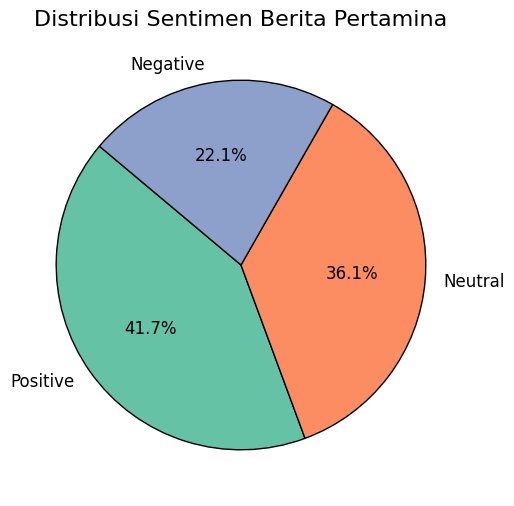

In [27]:
# Visualisasi Distribusi Sentimen
plt.figure(figsize=(8,6))
colors = ['#66c2a5','#fc8d62','#8da0cb']  # hijau, orange, biru
df['Sentimen'].value_counts().plot.pie(
    autopct='%1.1f%%', colors=colors, startangle=140,
    textprops={'fontsize':12}, wedgeprops={'edgecolor':'k'}
)
plt.title('Distribusi Sentimen Berita Pertamina', fontsize=16)
plt.ylabel('')
plt.show()

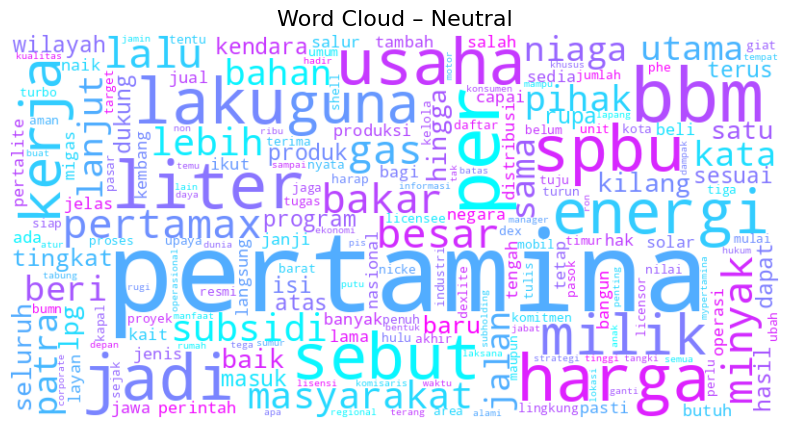

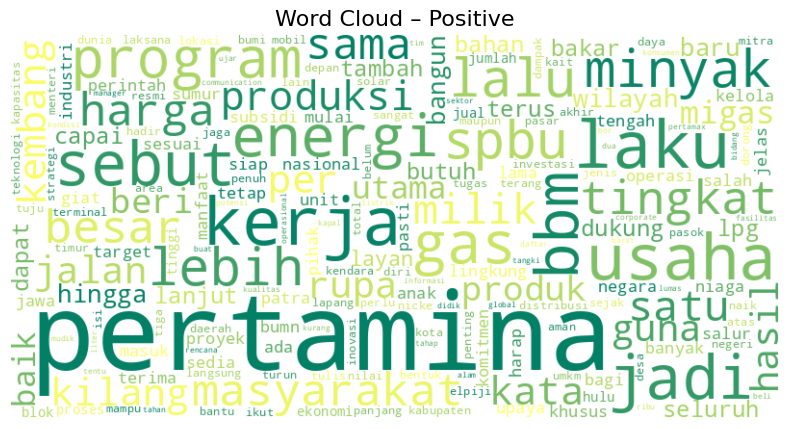

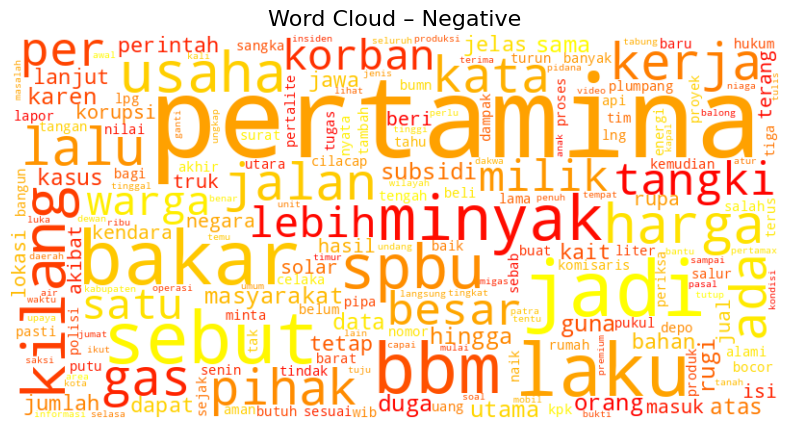

In [28]:
# Visualisasi Word Cloud per Sentimen
color_maps = {'Positive':'summer', 'Negative':'autumn', 'Neutral':'cool'}
sentiments = df['Sentimen'].unique()
for sentiment in sentiments:
    text = ' '.join(df[df['Sentimen']==sentiment]['final_text_stemmed'].dropna())
    if text:
        wc = WordCloud(width=800, height=400, background_color='white',
                       colormap=color_maps.get(sentiment,'Greys'), collocations=False).generate(text)
        plt.figure(figsize=(10,5))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Word Cloud – {sentiment}', fontsize=16)
        plt.show()

/tmp/ipykernel_3470/3221535098.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq.values, y=freq.index, palette='Set2', ax=ax)
/tmp/ipykernel_3470/3221535098.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq.values, y=freq.index, palette='Set2', ax=ax)
/tmp/ipykernel_3470/3221535098.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq.values, y=freq.index, palette='Set2', ax=ax)


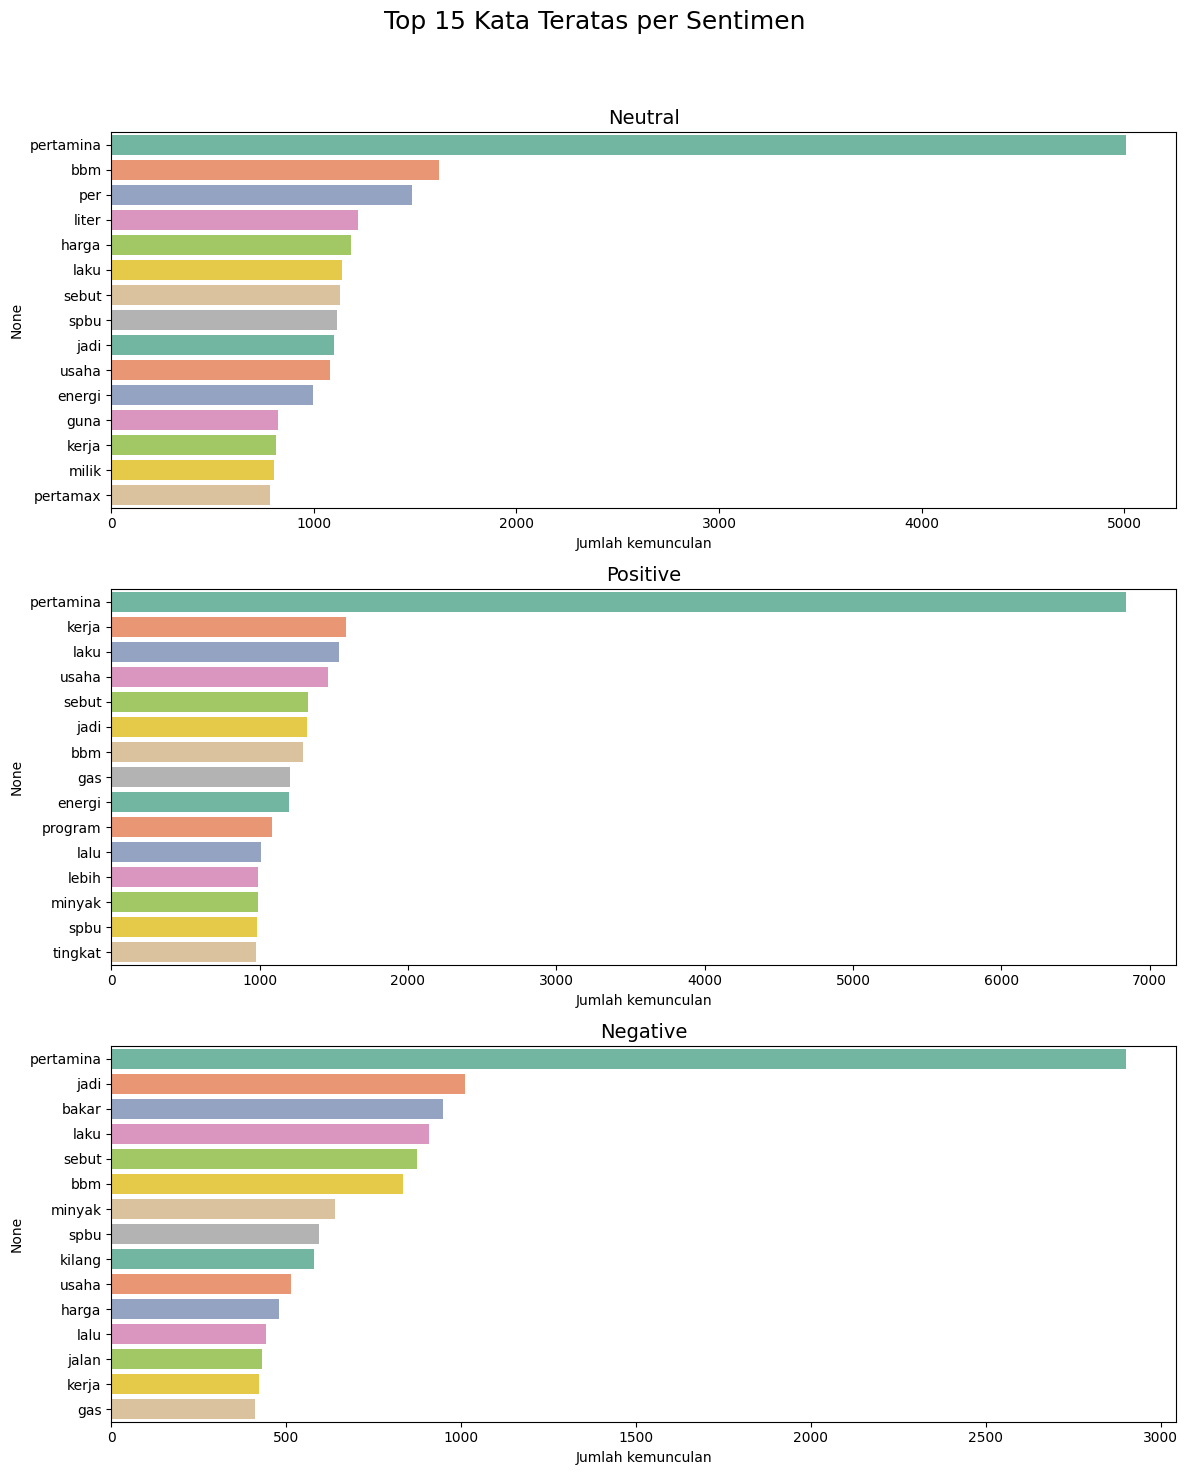

In [29]:
# Visualisasi Frekuensi Kata Teratas per Sentimen
sentiments = df['Sentimen'].unique()
fig, axes = plt.subplots(len(sentiments),1, figsize=(12,5*len(sentiments)))
fig.suptitle('Top 15 Kata Teratas per Sentimen', fontsize=18)

if len(sentiments)==1:
    axes=[axes]

for i, sentiment in enumerate(sentiments):
    corpus = ' '.join(df[df['Sentimen']==sentiment]['final_text_stemmed'].dropna())
    words = corpus.split()
    freq = pd.Series(words).value_counts().head(15)
    ax = axes[i]
    sns.barplot(x=freq.values, y=freq.index, palette='Set2', ax=ax)
    ax.set_title(f'{sentiment}', fontsize=14)
    ax.set_xlabel('Jumlah kemunculan')
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

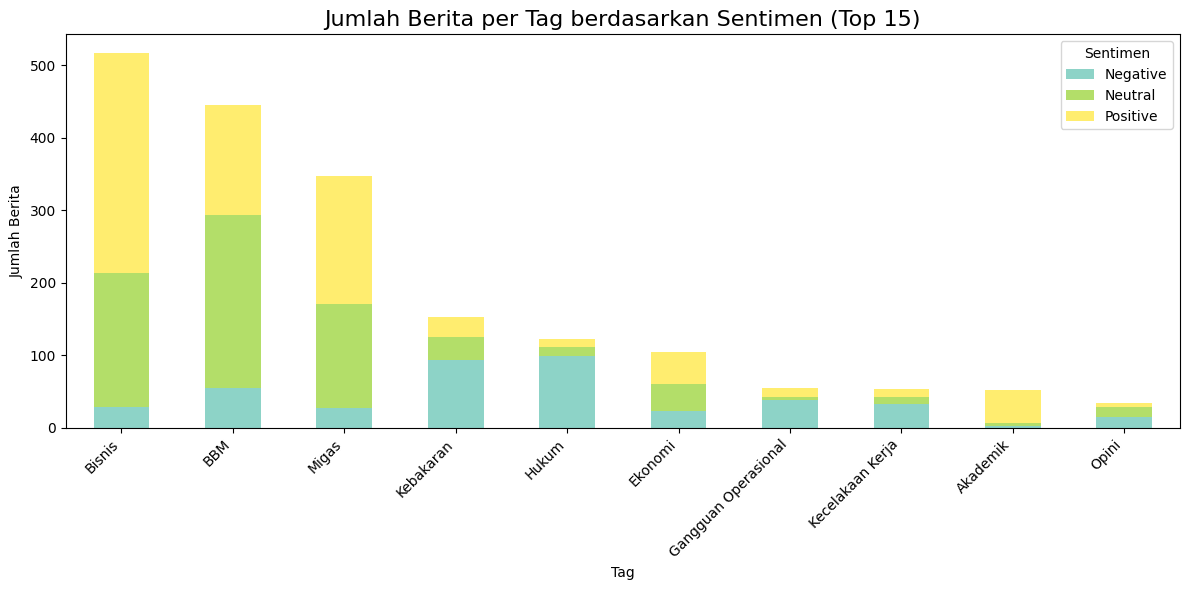

In [30]:
# Distribusi sentiment berdasarkan Tag
tag_sentiment_counts = df.groupby(['Tag','Sentimen']).size().unstack(fill_value=0)
top_tags = df['Tag'].value_counts().head(15).index
tag_sentiment_counts.loc[top_tags].plot(
    kind='bar', stacked=True, figsize=(12,6), colormap='Set3'
)
plt.title('Jumlah Berita per Tag berdasarkan Sentimen (Top 15)', fontsize=16)
plt.xlabel('Tag')
plt.ylabel('Jumlah Berita')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentimen')
plt.tight_layout()
plt.show()

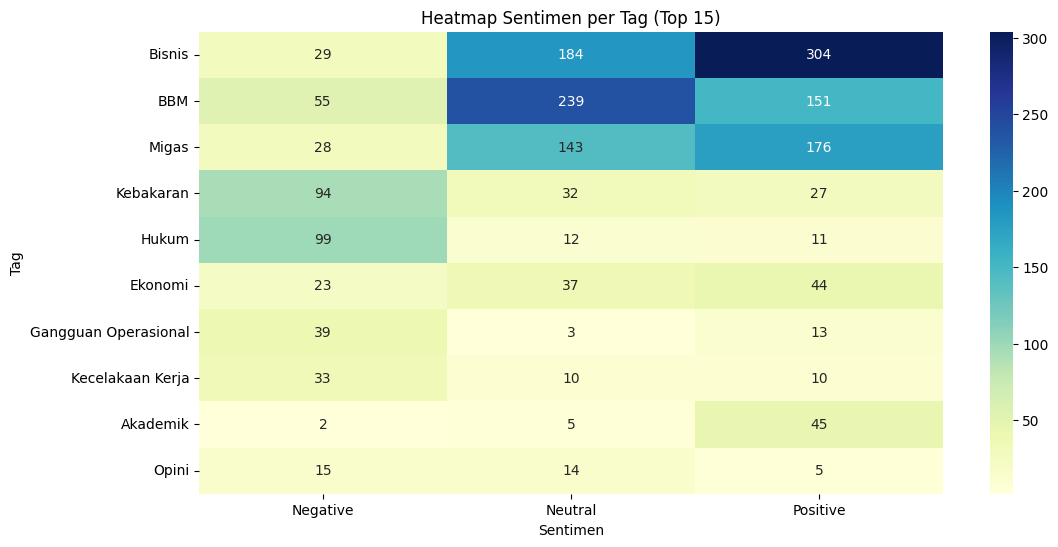

In [31]:
plt.figure(figsize=(12,6))
sns.heatmap(tag_sentiment_counts.loc[top_tags], annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap Sentimen per Tag (Top 15)')
plt.show()

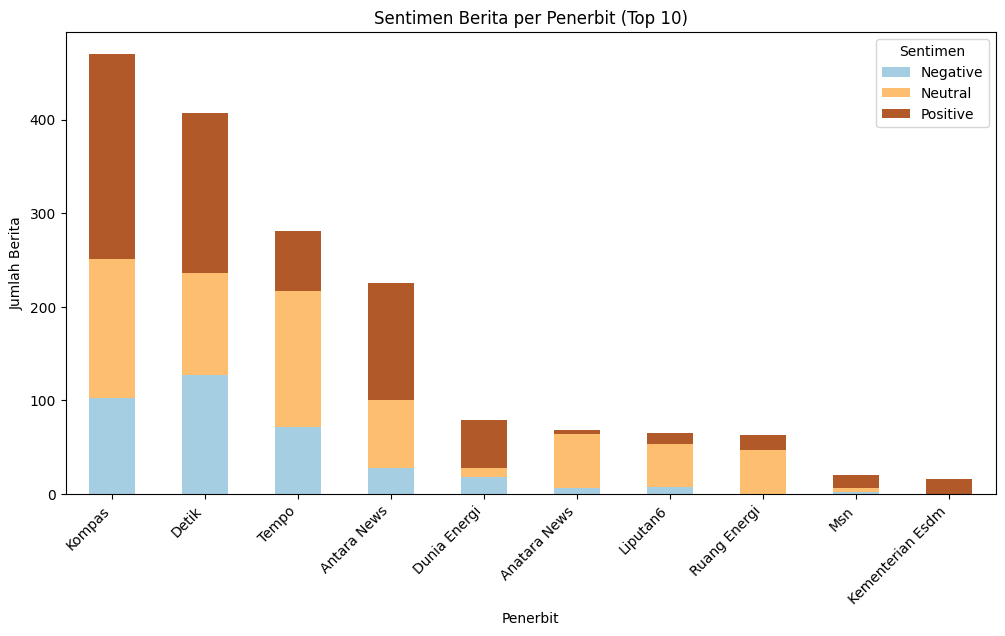

In [32]:
# Distribusi sentiment berdasarkan penerbit
publisher_sentiment = df.groupby(['Penerbit','Sentimen']).size().unstack(fill_value=0)

# Bisa ambil top 10 penerbit
top_publishers = df['Penerbit'].value_counts().head(10).index
publisher_sentiment.loc[top_publishers].plot(kind='bar', stacked=True, figsize=(12,6), colormap='Paired')
plt.title('Sentimen Berita per Penerbit (Top 10)')
plt.xlabel('Penerbit')
plt.ylabel('Jumlah Berita')
plt.xticks(rotation=45, ha='right')
plt.show()

/tmp/ipykernel_3470/2887680753.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sentimen', y='jumlah_kata', data=df, palette='pastel')


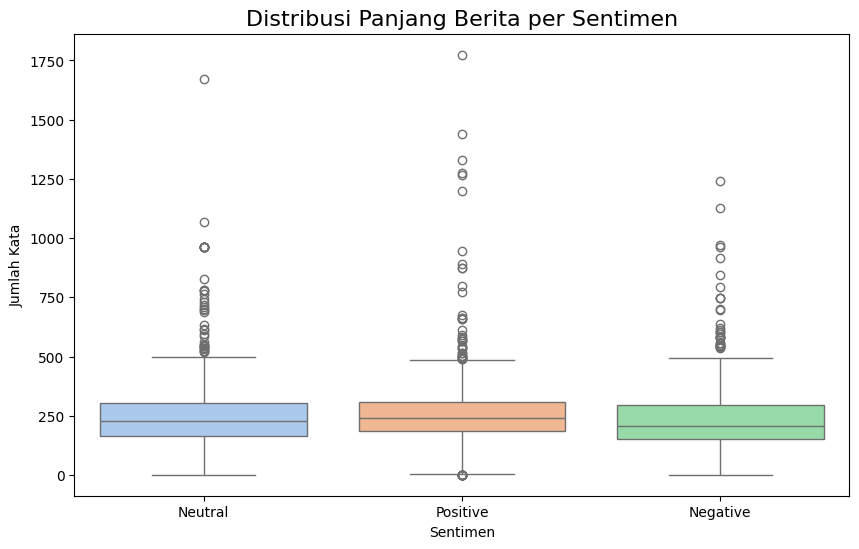

In [33]:
# Panjang Berita per Sentimen
df['jumlah_kata'] = df['final_text_stemmed'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(10,6))
sns.boxplot(x='Sentimen', y='jumlah_kata', data=df, palette='pastel')
plt.title('Distribusi Panjang Berita per Sentimen', fontsize=16)
plt.ylabel('Jumlah Kata')
plt.show()

In [34]:
# Tren sentiment
if 'Tanggal' in df.columns:
    df['Tanggal_Format'] = pd.to_datetime(df['Tanggal'], errors='coerce')
    df_time = df.dropna(subset=['Tanggal_Format']).copy()
    df_time.set_index('Tanggal_Format', inplace=True)
    trend = df_time.groupby([pd.Grouper(freq='M'),'Sentimen']).size().unstack(fill_value=0)

    trend.plot(kind='area', stacked=True, figsize=(14,7), alpha=0.6, colormap='Set2')
    plt.title('Tren Sentimen Berita Pertamina per Bulan (Area Chart)', fontsize=16)
    plt.xlabel('Bulan')
    plt.ylabel('Jumlah Berita')
    plt.show()

## Simpan hasil

In [35]:
output_path = '/content/drive/MyDrive/ProjectA-PBA/hasil_eda_pertamina.csv'
df.to_csv(output_path, index=False, encoding='utf-8')
print(f"Hasil EDA tersimpan")

Hasil EDA tersimpan
